In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


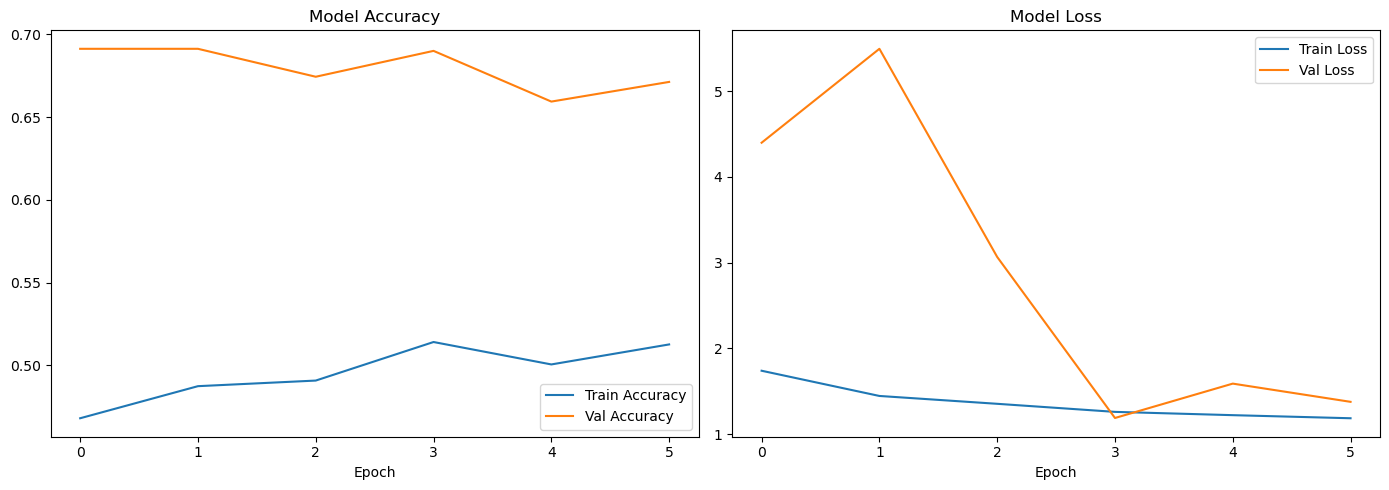

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.savefig("models/training_history.png")
plt.show()

258/258 ━━━━━━━━━━━━━━━━━━━━ 133s 510ms/step
Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       199
                     Pepper__bell___healthy       0.00      0.00      0.00       295
                               PlantVillage       0.50      1.00      0.67      4127
                      Potato___Early_blight       0.00      0.00      0.00       200
                       Potato___Late_blight       0.00      0.00      0.00       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.00      0.00      0.00       425
                        Tomato_Early_blight       0.00      0.00      0.00       200
                         Tomato_Late_blight       0.00      0.00      0.00       381
                           Tomato_Leaf_Mold       0.00      0.00      0.00      

C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

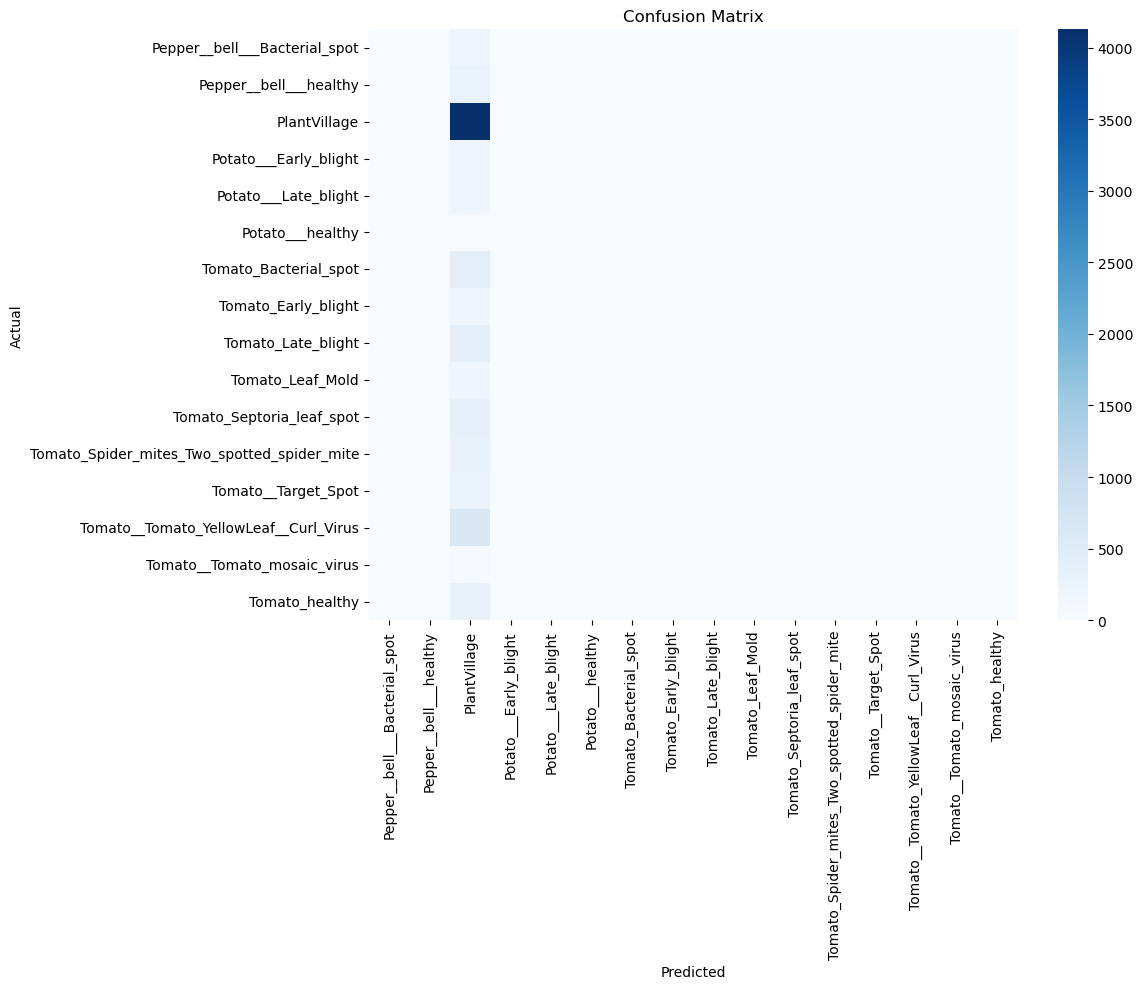

In [10]:
val_generator.reset()
predictions = model.predict(val_generator, steps=len(val_generator))
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes[:len(y_pred)]

class_labels = list(val_generator.class_indices.keys())

print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

with open("models/performance_report.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("models/confusion_matrix.png")
plt.show()

In [11]:
model.save("models/plant_disease_model.h5")
print("Model saved to models/plant_disease_model.h5")

import json
with open("models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)
print("Class indices saved to models/class_indices.json")

Model saved to models/plant_disease_model.h5
Class indices saved to models/class_indices.json


Actual class: Tomato_Leaf_Mold
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step


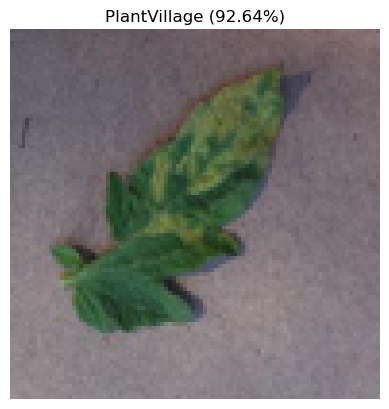

Predicted: PlantVillage (92.64% confidence)


In [12]:
def predict_disease(img_path, model, class_indices, img_size=IMG_SIZE):
    idx_to_class = {v: k for k, v in class_indices.items()}

    img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_class = idx_to_class[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.title(f"{pred_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return pred_class, confidence

# Test it on a random sample image
test_cls = random.choice(class_names)
test_cls_path = os.path.join(data_dir, test_cls)
test_img = os.path.join(test_cls_path, random.choice(os.listdir(test_cls_path)))

print("Actual class:", test_cls)
predicted_class, confidence = predict_disease(test_img, model, train_generator.class_indices)
print(f"Predicted: {predicted_class} ({confidence:.2f}% confidence)")

In [14]:
dashboard_code = '''
import streamlit as st
import numpy as np
from PIL import Image
import json
import tensorflow as tf

st.set_page_config(page_title="Plant Disease Detector", page_icon="🌿", layout="centered")

IMG_SIZE = 96

@st.cache_resource
def load_model():
    model = tf.keras.models.load_model("models/plant_disease_model.h5")
    with open("models/class_indices.json", "r") as f:
        class_indices = json.load(f)
    idx_to_class = {v: k for k, v in class_indices.items()}
    return model, idx_to_class

model, idx_to_class = load_model()

st.title("🌿 Plant Disease Detection System")
st.write("Upload a leaf image and the model will predict whether the plant is healthy or diseased.")

uploaded_file = st.file_uploader("Choose a leaf image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    with st.spinner("Analyzing leaf image..."):
        prediction = model.predict(img_array)
        pred_idx = np.argmax(prediction)
        pred_class = idx_to_class[pred_idx]
        confidence = np.max(prediction) * 100

    st.subheader("Prediction Result")

    if "healthy" in pred_class.lower():
        st.success(f"✅ {pred_class}")
    else:
        st.error(f"⚠️ {pred_class}")

    st.write(f"**Confidence:** {confidence:.2f}%")

    st.subheader("Top 3 Predictions")
    top_indices = prediction[0].argsort()[-3:][::-1]
    for idx in top_indices:
        st.write(f"- {idx_to_class[idx]}: {prediction[0][idx]*100:.2f}%")

st.markdown("---")
st.caption("Plant Disease Detection System | CNN Model trained on PlantVillage Dataset")
'''

import os
os.makedirs("dashboard", exist_ok=True)
with open("dashboard/app.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("Dashboard saved to dashboard/app.py")

Dashboard saved to dashboard/app.py


In [15]:
!pip install streamlit -q

In [4]:
import shutil

sample_dir = "sample_test_images"
os.makedirs(sample_dir, exist_ok=True)

sample_classes_to_test = random.sample(class_names, min(5, len(class_names)))

for cls in sample_classes_to_test:
    cls_path = os.path.join(data_dir, cls)
    img_file = random.choice(os.listdir(cls_path))
    src = os.path.join(cls_path, img_file)
    dst = os.path.join(sample_dir, f"{cls}_{img_file}")
    shutil.copy(src, dst)
    print(f"Copied: {dst}")

print(f"\nSample images saved in: {os.path.abspath(sample_dir)}")

Copied: sample_test_images\Tomato_Bacterial_spot_ef588b6e-ce90-4648-b1a4-990dc7dca22d___UF.GRC_BS_Lab Leaf 9288.JPG
Copied: sample_test_images\Tomato_Leaf_Mold_6fd472fe-cc75-4762-a3fa-2428649907c8___Crnl_L.Mold 7156.JPG
Copied: sample_test_images\Potato___Early_blight_24fb74df-0aa9-4e89-9ba4-55a4664438ab___RS_Early.B 8634.JPG
Copied: sample_test_images\Tomato__Tomato_mosaic_virus_b32647fc-d502-4bb4-99f6-3003874daee4___PSU_CG 2246.JPG
Copied: sample_test_images\Tomato_Septoria_leaf_spot_fe18d20c-3e3c-4fbf-9a11-c38228c6eb8e___JR_Sept.L.S 2623.JPG

Sample images saved in: C:\Users\MERLIN J\sample_test_images


In [1]:
print(open("models/performance_report.txt").read())

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       199
                     Pepper__bell___healthy       0.00      0.00      0.00       295
                               PlantVillage       0.50      1.00      0.67      4127
                      Potato___Early_blight       0.00      0.00      0.00       200
                       Potato___Late_blight       0.00      0.00      0.00       200
                           Potato___healthy       0.00      0.00      0.00        30
                      Tomato_Bacterial_spot       0.00      0.00      0.00       425
                        Tomato_Early_blight       0.00      0.00      0.00       200
                         Tomato_Late_blight       0.00      0.00      0.00       381
                           Tomato_Leaf_Mold       0.00      0.00      0.00       190
                  Tomato_Septoria_leaf_spot       0.00      0.00

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
print("Imports done.")

Imports done.


In [4]:
import kagglehub
path = kagglehub.dataset_download("emmarex/plantdisease")
print("Base path:", path)
print("Contents of base path:")
for item in os.listdir(path):
    print(" -", item)

Base path: C:\Users\MERLIN J\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1
Contents of base path:
 - PlantVillage


In [5]:
data_dir = os.path.join(path, "PlantVillage")
print("Contents of data_dir:")
for item in os.listdir(data_dir):
    full_path = os.path.join(data_dir, item)
    if os.path.isdir(full_path):
        n_files = len(os.listdir(full_path))
        print(f"{item}: {n_files} items")

Contents of data_dir:
Pepper__bell___Bacterial_spot: 997 items
Pepper__bell___healthy: 1478 items
PlantVillage: 15 items
Potato___Early_blight: 1000 items
Potato___healthy: 152 items
Potato___Late_blight: 1000 items
Tomato_Bacterial_spot: 2127 items
Tomato_Early_blight: 1000 items
Tomato_healthy: 1591 items
Tomato_Late_blight: 1909 items
Tomato_Leaf_Mold: 952 items
Tomato_Septoria_leaf_spot: 1771 items
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 items
Tomato__Target_Spot: 1404 items
Tomato__Tomato_mosaic_virus: 373 items
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 items


In [6]:
# Explicitly list only the real 15 class folders, excluding the nested "PlantVillage" duplicate
class_names = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d != "PlantVillage"
])

print("Real classes:", len(class_names))
print(class_names)

IMG_SIZE = 96
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    classes=class_names   # <-- key fix: only use real classes
)

val_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    classes=class_names   # <-- key fix
)

num_classes = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Real classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [7]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459,983 (1.75 MB)

 Trainable params: 459,023 (1.75 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

os.makedirs("models", exist_ok=True)

EPOCHS = 15

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint("models/best_model.h5", monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    steps_per_epoch=200,
    validation_steps=60,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.5559 - loss: 1.3966
Epoch 1: val_accuracy improved from None to 0.17604, saving model to models/best_model.h5



Epoch 1: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 116s 552ms/step - accuracy: 0.5559 - loss: 1.3966 - val_accuracy: 0.1760 - val_loss: 6.3255 - learning_rate: 0.0010
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.6800 - loss: 0.9697
Epoch 2: val_accuracy improved from 0.17604 to 0.21042, saving model to models/best_model.h5



Epoch 2: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 108s 541ms/step - accuracy: 0.6800 - loss: 0.9697 - val_accuracy: 0.2104 - val_loss: 4.9496 - learning_rate: 0.0010
Epoch 3/15
117/200 ━━━━━━━━━━━━━━━━━━━━ 39s 471ms/step - accuracy: 0.7361 - loss: 0.7764

C:\Users\MERLIN J\Downloads\anacoda\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 3: val_accuracy improved from 0.21042 to 0.31719, saving model to models/best_model.h5



Epoch 3: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 344ms/step - accuracy: 0.7361 - loss: 0.7764 - val_accuracy: 0.3172 - val_loss: 3.3240 - learning_rate: 0.0010
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.7653 - loss: 0.7012
Epoch 4: val_accuracy improved from 0.31719 to 0.75313, saving model to models/best_model.h5



Epoch 4: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 113s 567ms/step - accuracy: 0.7653 - loss: 0.7012 - val_accuracy: 0.7531 - val_loss: 0.7230 - learning_rate: 0.0010
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8030 - loss: 0.5964
Epoch 5: val_accuracy did not improve from 0.75313
200/200 ━━━━━━━━━━━━━━━━━━━━ 115s 578ms/step - accuracy: 0.8030 - loss: 0.5964 - val_accuracy: 0.4104 - val_loss: 2.1407 - learning_rate: 0.0010
Epoch 6/15
117/200 ━━━━━━━━━━━━━━━━━━━━ 40s 491ms/step - accuracy: 0.8130 - loss: 0.5555
Epoch 6: val_accuracy did not improve from 0.75313
200/200 ━━━━━━━━━━━━━━━━━━━━ 72s 359ms/step - accuracy: 0.8130 - loss: 0.5555 - val_accuracy: 0.2979 - val_loss: 4.1810 - learning_rate: 0.0010
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.8360 - loss: 0.4930
Epoch 7: val_accuracy did not improve from 0.75313

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
200/200 ━━━━━━━


Epoch 9: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 73s 367ms/step - accuracy: 0.9020 - loss: 0.3094 - val_accuracy: 0.9047 - val_loss: 0.3009 - learning_rate: 5.0000e-04
Epoch 10/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8936 - loss: 0.3088
Epoch 10: val_accuracy did not improve from 0.90469
200/200 ━━━━━━━━━━━━━━━━━━━━ 145s 726ms/step - accuracy: 0.8936 - loss: 0.3088 - val_accuracy: 0.9016 - val_loss: 0.2812 - learning_rate: 5.0000e-04
Epoch 11/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.9041 - loss: 0.2929
Epoch 11: val_accuracy improved from 0.90469 to 0.91927, saving model to models/best_model.h5



Epoch 11: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 140s 699ms/step - accuracy: 0.9041 - loss: 0.2929 - val_accuracy: 0.9193 - val_loss: 0.2429 - learning_rate: 5.0000e-04
Epoch 12/15
117/200 ━━━━━━━━━━━━━━━━━━━━ 48s 586ms/step - accuracy: 0.9132 - loss: 0.2699
Epoch 12: val_accuracy did not improve from 0.91927
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 421ms/step - accuracy: 0.9132 - loss: 0.2699 - val_accuracy: 0.8964 - val_loss: 0.3102 - learning_rate: 5.0000e-04
Epoch 13/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.9145 - loss: 0.2525
Epoch 13: val_accuracy did not improve from 0.91927
200/200 ━━━━━━━━━━━━━━━━━━━━ 139s 696ms/step - accuracy: 0.9145 - loss: 0.2525 - val_accuracy: 0.8948 - val_loss: 0.3002 - learning_rate: 5.0000e-04
Epoch 14/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9201 - loss: 0.2475
Epoch 14: val_accuracy did not improve from 0.91927

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743


Epoch 15: finished saving model to models/best_model.h5
200/200 ━━━━━━━━━━━━━━━━━━━━ 77s 386ms/step - accuracy: 0.9207 - loss: 0.2363 - val_accuracy: 0.9510 - val_loss: 0.1602 - learning_rate: 2.5000e-04


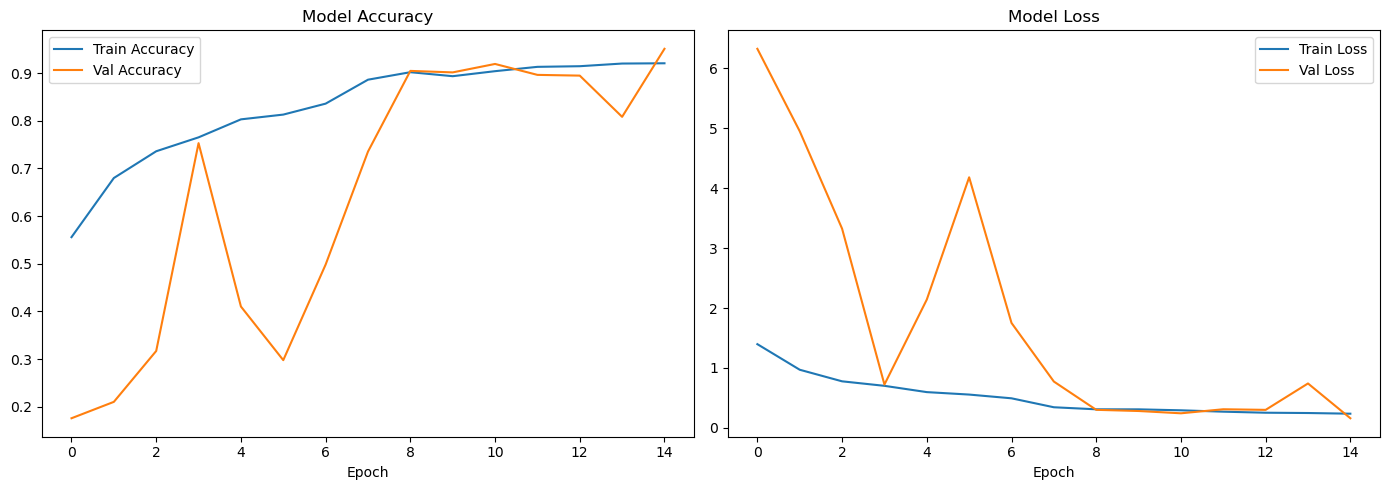

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend()

plt.tight_layout()
plt.savefig("models/training_history.png")
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 226ms/step
Classification Report:

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.92      0.96       199
                     Pepper__bell___healthy       0.96      0.99      0.97       295
                      Potato___Early_blight       1.00      0.96      0.98       200
                       Potato___Late_blight       0.94      0.95      0.95       200
                           Potato___healthy       1.00      0.80      0.89        30
                      Tomato_Bacterial_spot       0.97      0.98      0.97       425
                        Tomato_Early_blight       0.90      0.86      0.88       200
                         Tomato_Late_blight       0.90      0.94      0.92       381
                           Tomato_Leaf_Mold       0.96      0.95      0.95       190
                  Tomato_Septoria_leaf_spot       0.98      0.96      0.97       

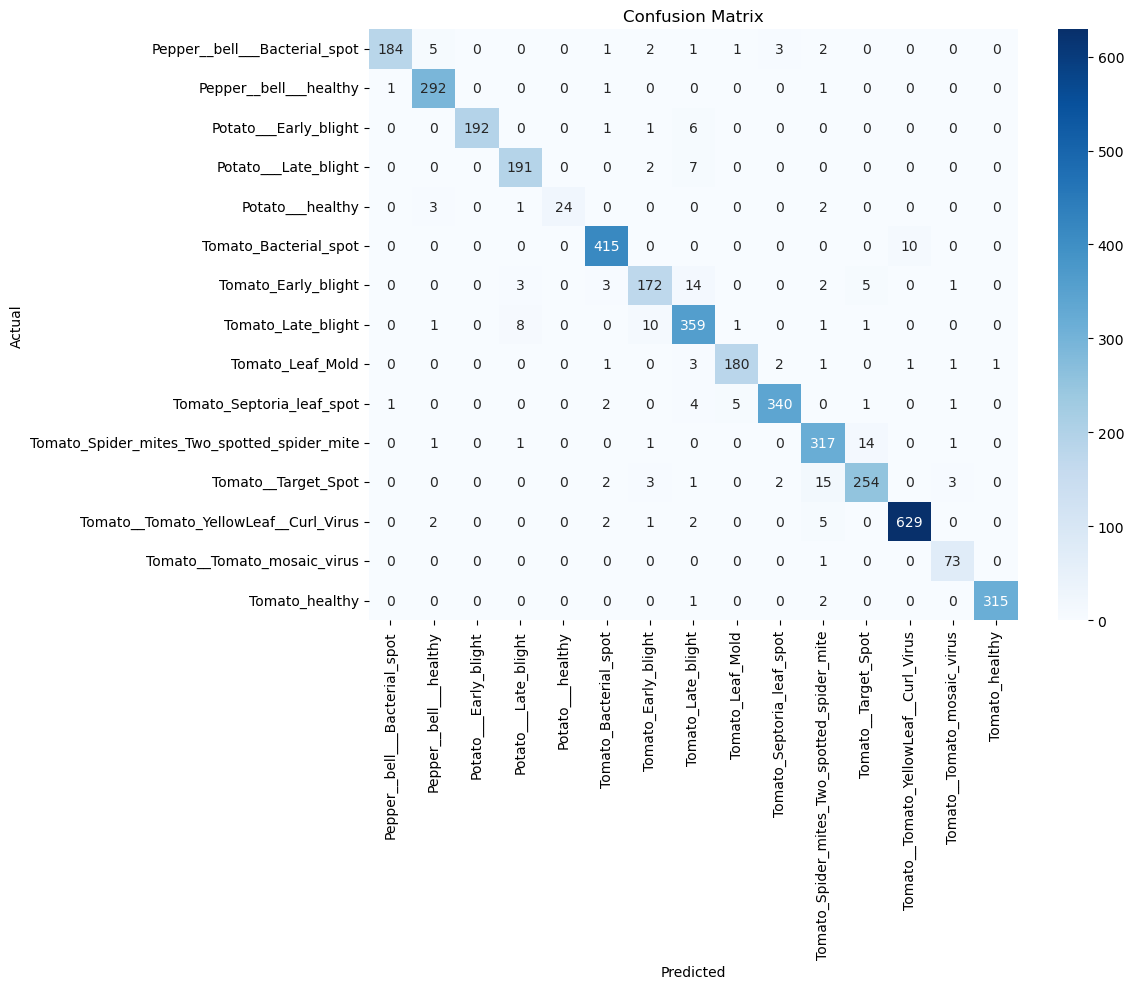

In [10]:
val_generator.reset()
predictions = model.predict(val_generator, steps=len(val_generator))
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes[:len(y_pred)]

class_labels = list(val_generator.class_indices.keys())

print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

with open("models/performance_report.txt", "w") as f:
    f.write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("models/confusion_matrix.png")
plt.show()

In [11]:
model.save("models/plant_disease_model.h5")
print("Model saved.")

import json
with open("models/class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)
print("Class indices saved.")

Model saved.
Class indices saved.


In [12]:
print(open("models/performance_report.txt").read())

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.92      0.96       199
                     Pepper__bell___healthy       0.96      0.99      0.97       295
                      Potato___Early_blight       1.00      0.96      0.98       200
                       Potato___Late_blight       0.94      0.95      0.95       200
                           Potato___healthy       1.00      0.80      0.89        30
                      Tomato_Bacterial_spot       0.97      0.98      0.97       425
                        Tomato_Early_blight       0.90      0.86      0.88       200
                         Tomato_Late_blight       0.90      0.94      0.92       381
                           Tomato_Leaf_Mold       0.96      0.95      0.95       190
                  Tomato_Septoria_leaf_spot       0.98      0.96      0.97       354
Tomato_Spider_mites_Two_spotted_spider_mite       0.91      0.95